# Dynamic Noise Map over AlphaEarth Embeddings

**All training is in `train_noise_model.py`.** of [my repo](https://github.com/subash-khanal/NoiseMap.git). This notebook is for **inference only**: load the saved model and use it.

1. **Load data** + **EDA** — explore noisecapture_prepared.parquet.
2. **Load model** — checkpoint and preprocess from Google Drive (or local).
3. **Dynamic noisemap demo** — select region and time → predicted noise (dB) map over AEF.

**Pre-trained model:** Checkpoint and preprocess are provided in [Google Drive (public_playground)](https://drive.google.com/drive/folders/1lbL3juj2hkUhBTDJL78wvlb5F6SIDtAe). The notebook downloads them automatically if not found locally. Optionally, run `train_noise_model.py` and set `CKPT_DIR` to use your own checkpoints.

## 1. Setup & Load data from Google Drive

Data file: [noisecapture_prepared.parquet](https://drive.google.com/file/d/1iQx7NaDg1GkN7ZbQLeNyMmFIHczsNUfT/view?usp=drive_link) (prepared by `data_prep/prep_data.py`).

In [ ]:
# Optional: uncomment to install heatmap deps early (or they install on first heatmap run)
# !pip install -q gdown aef-loader odc-geo pyproj nest_asyncio

In [1]:
# Run in Colab: mount Drive and install deps if needed
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  !pip install -q pyarrow pandas matplotlib seaborn scikit-learn torch gdown
  !pip install -q aef-loader odc-geo pyproj nest_asyncio ipyleaflet
else:
  %pip install -q pyarrow pandas matplotlib seaborn scikit-learn torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Data path: use Drive file ID for direct download in Colab, or local path
FILE_ID = '1iQx7NaDg1GkN7ZbQLeNyMmFIHczsNUfT'
PARQUET_NAME = 'noisecapture_prepared.parquet'

def load_data():
  if IN_COLAB:
    # Option A: file already in Drive (e.g. in My Drive/NoiseMap/)
    drive_path = Path('/content/drive/My Drive')
    for candidate in [drive_path / 'NoiseMap' / PARQUET_NAME,
                      drive_path / PARQUET_NAME,
                      Path('/content') / PARQUET_NAME]:
      if candidate.exists():
        return pd.read_parquet(candidate)
    # Option B: download with gdown
    !pip install -q gdown
    import gdown
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    out = '/content/noisecapture_prepared.parquet'
    gdown.download(url, out, quiet=False, fuzzy=True)
    return pd.read_parquet(out)
  else:
    # Local: try common locations
    for p in [Path('data_prep') / PARQUET_NAME, Path(PARQUET_NAME)]:
      if p.exists():
        return pd.read_parquet(p)
    raise FileNotFoundError('Parquet not found. In Colab, add file to Drive or use gdown.')

df = load_data()
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.8 MB/s eta 0:00:00
Device: cpu


Downloading...
From: https://drive.google.com/uc?id=1iQx7NaDg1GkN7ZbQLeNyMmFIHczsNUfT
To: /content/noisecapture_prepared.parquet
100%|██████████| 50.4M/50.4M [00:00<00:00, 112MB/s]


Shape: (499970, 12)
Columns: ['lon', 'lat', 'noise_level_dB', 'time_epoch', 'datetime_utc', 'hour', 'hour_sin', 'hour_cos', 'is_night', 'country', 'AEF_embed', 'geometry']


,lon,lat,noise_level_dB,time_epoch,datetime_utc,hour,hour_sin,hour_cos,is_night,country,AEF_embed,geometry
0,67.092992,36.701262,59.02,1596790246000,2020-08-07 08:50:46+00:00,8.833333,0.737277,-0.675590,False,Afghanistan,"[0.14173009991645813, 0.02977316454052925, 0.2...",b'\x01\x01\x00\x00\x00$M\xb4\x92\xf3\xc5P@\xde...
1,67.101926,36.669848,100.34,1646930213000,2022-03-10 16:36:53+00:00,16.600000,-0.933580,-0.358368,False,Afghanistan,"[0.21413302421569824, 0.119092658162117, 0.071...",b'\x01\x01\x00\x00\x00\xd6\xf0\x80\xf4\x85\xc6...
2,67.123022,36.717551,40.52,1721071602000,2024-07-15 19:26:42+00:00,19.433333,-0.930418,0.366501,False,Afghanistan,"[0.1599999964237213, -0.010396001860499382, 0....",b'\x01\x01\x00\x00\x00\x18\xc2D\x96\xdf\xc7P@5...
3,67.123124,36.717544,40.35,1721083443000,2024-07-15 22:44:03+00:00,22.733333,-0.325568,0.945519,True,Afghanistan,"[0.1599999964237213, -0.010396001860499382, 0....",b'\x01\x01\x00\x00\x00\x9bl\x16B\xe1\xc7P@e\x8...
4,67.123115,36.717517,30.36,1721083898000,2024-07-15 22:51:38+00:00,22.850000,-0.296542,0.955020,True,Afghanistan,"[0.1599999964237213, -0.010396001860499382, 0....",b'\x01\x01\x00\x00\x00i\xa9\xbc\x1d\xe1\xc7P@\...


## 2. Exploratory Data Analysis

In [2]:
# Drop rows with missing AEF_embed (required for ML)
df_clean = df.dropna(subset=['AEF_embed']).copy()
if 'geometry' in df_clean.columns:
  df_clean = df_clean.drop(columns=['geometry'])
print('Rows with valid AEF_embed:', len(df_clean))
df_clean.head()

Rows with valid AEF_embed: 499122


,lon,lat,noise_level_dB,time_epoch,datetime_utc,hour,hour_sin,hour_cos,is_night,country,AEF_embed
0,67.092992,36.701262,59.02,1596790246000,2020-08-07 08:50:46+00:00,8.833333,0.737277,-0.675590,False,Afghanistan,"[0.14173009991645813, 0.02977316454052925, 0.2..."
1,67.101926,36.669848,100.34,1646930213000,2022-03-10 16:36:53+00:00,16.600000,-0.933580,-0.358368,False,Afghanistan,"[0.21413302421569824, 0.119092658162117, 0.071..."
2,67.123022,36.717551,40.52,1721071602000,2024-07-15 19:26:42+00:00,19.433333,-0.930418,0.366501,False,Afghanistan,"[0.1599999964237213, -0.010396001860499382, 0...."
3,67.123124,36.717544,40.35,1721083443000,2024-07-15 22:44:03+00:00,22.733333,-0.325568,0.945519,True,Afghanistan,"[0.1599999964237213, -0.010396001860499382, 0...."
4,67.123115,36.717517,30.36,1721083898000,2024-07-15 22:51:38+00:00,22.850000,-0.296542,0.955020,True,Afghanistan,"[0.1599999964237213, -0.010396001860499382, 0...."


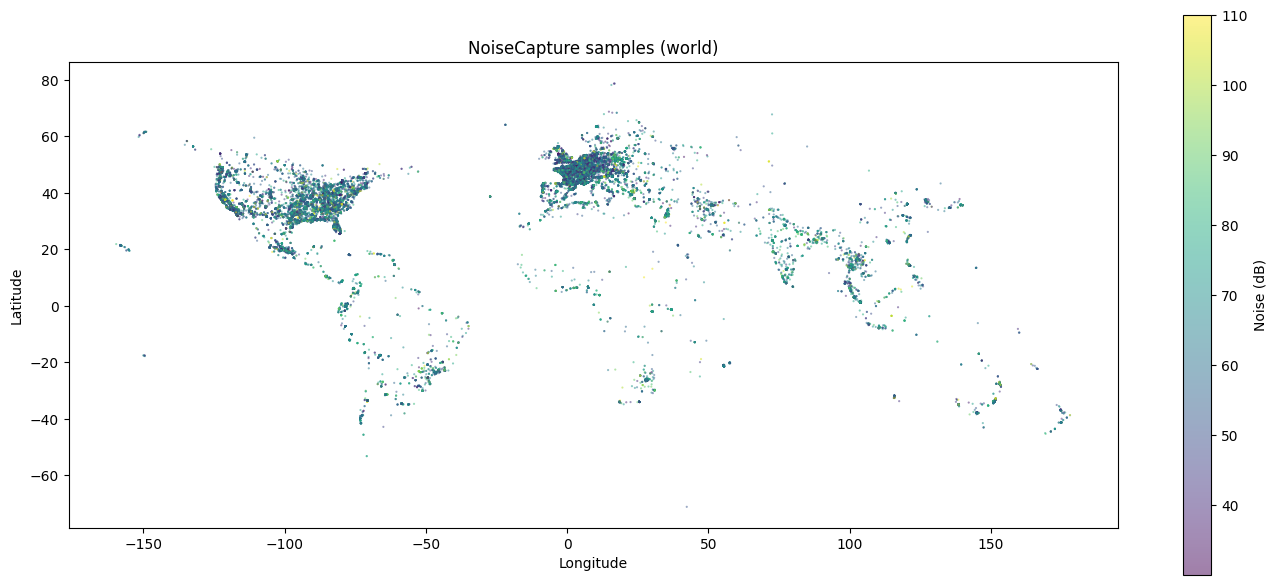

In [3]:
# Scatter: sample locations around the world (subsample for speed)
np.random.seed(42)
n_plot = min(50_000, len(df_clean))
sub = df_clean.sample(n_plot)
fig, ax = plt.subplots(figsize=(14, 6))
sc = ax.scatter(sub['lon'], sub['lat'], c=sub['noise_level_dB'], s=0.3, alpha=0.5, cmap='viridis')
plt.colorbar(sc, label='Noise (dB)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('NoiseCapture samples (world)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

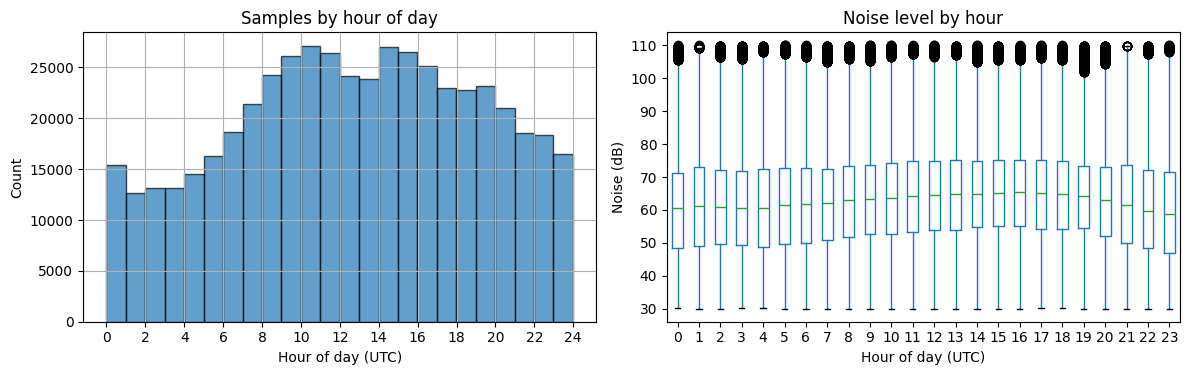

In [4]:
# Time / hour distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean['hour'].hist(bins=24, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Hour of day (UTC)')
axes[0].set_ylabel('Count')
axes[0].set_title('Samples by hour of day')
axes[0].set_xticks(range(0, 25, 2))
# Noise level by hour (binned)
df_clean.assign(hour_bin=(df_clean['hour'] // 1).astype(int)).boxplot(
  column='noise_level_dB', by='hour_bin', ax=axes[1], grid=False)
axes[1].set_xlabel('Hour of day (UTC)')
axes[1].set_ylabel('Noise (dB)')
axes[1].set_title('Noise level by hour')
plt.suptitle('')
plt.tight_layout()
plt.show()

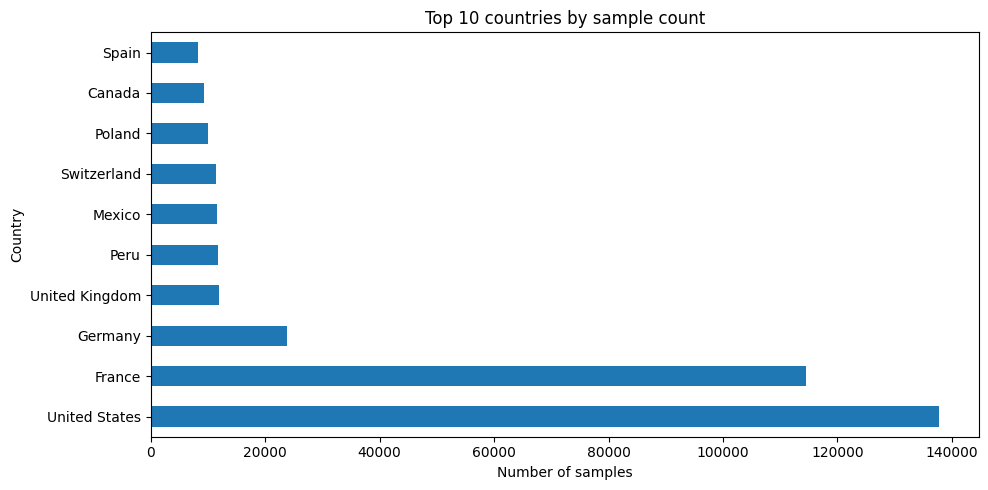

In [5]:
# Top 10 countries by sample count
top10 = df_clean['country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind='barh', ax=ax)
ax.set_xlabel('Number of samples')
ax.set_ylabel('Country')
ax.set_title('Top 10 countries by sample count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_589/107372175.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Day', 'Night'])


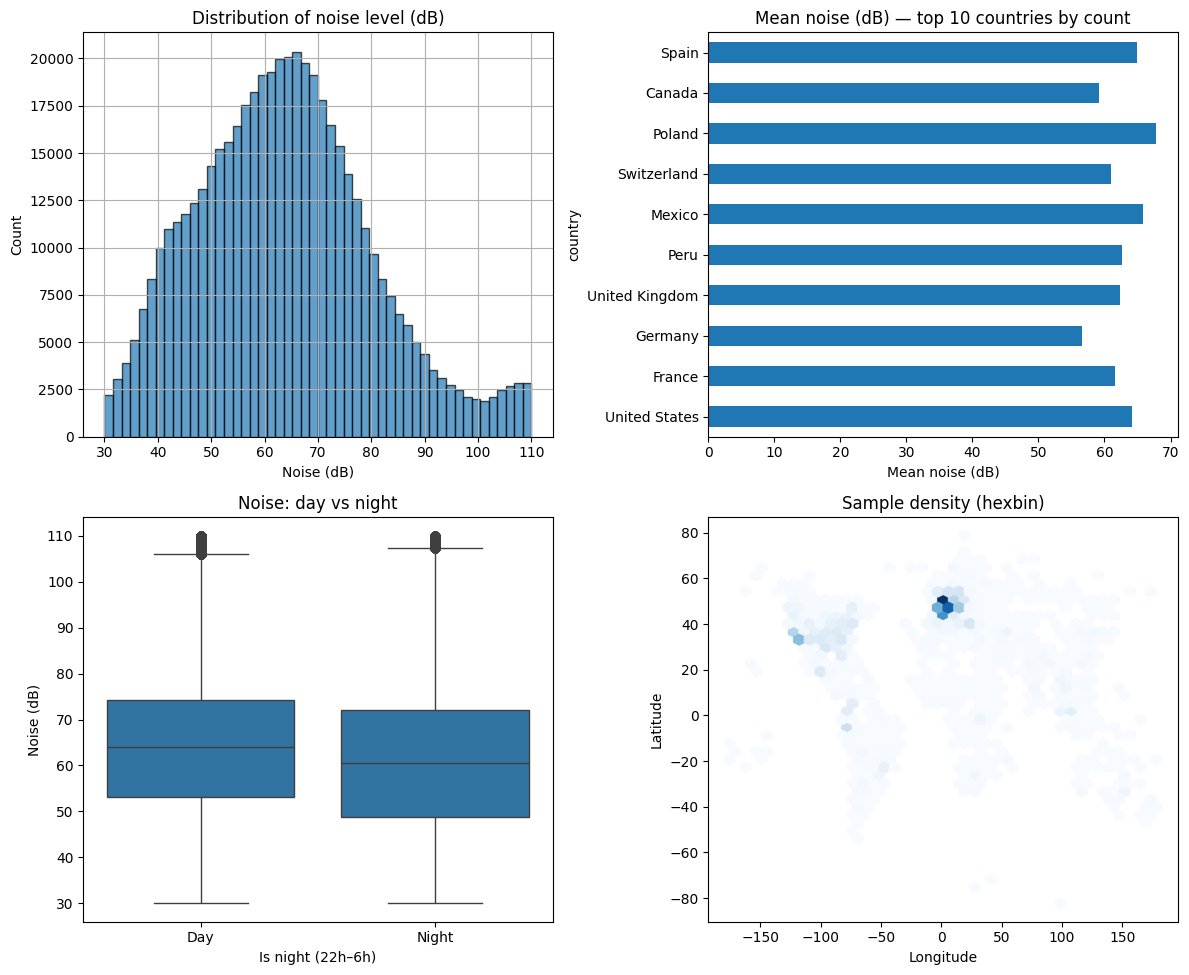

In [6]:
# Noise (dB) distribution and extra views
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df_clean['noise_level_dB'].hist(ax=axes[0,0], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_xlabel('Noise (dB)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distribution of noise level (dB)')
# Top 10: mean noise by country
by_country = df_clean.groupby('country')['noise_level_dB'].agg(['mean','count'])
by_country = by_country[by_country['count'] >= 100].nlargest(10, 'count')
by_country['mean'].plot(kind='barh', ax=axes[0,1])
axes[0,1].set_xlabel('Mean noise (dB)')
axes[0,1].set_title('Mean noise (dB) — top 10 countries by count')
# Day vs night
if 'is_night' in df_clean.columns:
  sns.boxplot(data=df_clean, x='is_night', y='noise_level_dB', ax=axes[1,0])
  axes[1,0].set_xticklabels(['Day', 'Night'])
  axes[1,0].set_xlabel('Is night (22h–6h)')
  axes[1,0].set_ylabel('Noise (dB)')
  axes[1,0].set_title('Noise: day vs night')
# Lat/lon density
axes[1,1].hexbin(df_clean['lon'], df_clean['lat'], gridsize=40, cmap='Blues', mincnt=1)
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')
axes[1,1].set_title('Sample density (hexbin)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 3. Load model and preprocess (from Google Drive or local)

Load the pre-trained checkpoint and preprocess from the [public_playground Drive folder](https://drive.google.com/drive/folders/1lbL3juj2hkUhBTDJL78wvlb5F6SIDtAe). If not found locally, they are downloaded automatically. These are used below for the **dynamic noisemap demo** (predictions over AEF for user-selected region and time).

In [7]:
import joblib
from torch import nn

# Pre-trained model: Google Drive public_playground folder
DRIVE_CKPT_FOLDER_ID = '1lbL3juj2hkUhBTDJL78wvlb5F6SIDtAe'
CKPT_DIR = Path('checkpoints')
if IN_COLAB:
  CKPT_DIR = Path('/content/drive/My Drive/NoiseMap')

ckpt_path = CKPT_DIR / 'noise_mlp_checkpoint.pt'
preprocess_path = CKPT_DIR / 'noise_mlp_preprocess.joblib'

# If not found locally, download from Google Drive
if not ckpt_path.exists() or not preprocess_path.exists():
  try:
    import gdown
  except ImportError:
    import subprocess
    import sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=False)
    import gdown
  download_dir = Path('/content/ckpts_drive') if IN_COLAB else Path('ckpts_drive')
  download_dir.mkdir(parents=True, exist_ok=True)
  gdown.download_folder(id=DRIVE_CKPT_FOLDER_ID, output=str(download_dir), quiet=False)
  # gdown may create a subfolder with the Drive folder name
  for candidate in [download_dir, *[p for p in download_dir.iterdir() if p.is_dir()]]:
    if (candidate / 'noise_mlp_checkpoint.pt').exists():
      CKPT_DIR = candidate
      break
  else:
    CKPT_DIR = download_dir
  ckpt_path = CKPT_DIR / 'noise_mlp_checkpoint.pt'
  preprocess_path = CKPT_DIR / 'noise_mlp_preprocess.joblib'

if not ckpt_path.exists():
  raise FileNotFoundError(f'Missing: {ckpt_path}. Download from https://drive.google.com/drive/folders/{DRIVE_CKPT_FOLDER_ID}')
if not preprocess_path.exists():
  raise FileNotFoundError(f'Missing: {preprocess_path}')

ckpt = torch.load(ckpt_path, map_location=device)
config = ckpt['config']
n_features = ckpt['n_features']

# Same architecture as train_noise_model.py (hidden from checkpoint)
class NoiseMLP(nn.Module):
  def __init__(self, n_in, hidden=(256, 256, 128, 64)):
    super().__init__()
    layers = []
    prev = n_in
    for h in hidden:
      layers += [nn.Linear(prev, h), nn.ReLU(inplace=True), nn.BatchNorm1d(h)]
      prev = h
    layers += [nn.Linear(prev, 1)]
    self.net = nn.Sequential(*layers)
  def forward(self, x):
    return self.net(x).squeeze(-1)

model = NoiseMLP(n_features, tuple(config['hidden'])).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

preprocess = joblib.load(preprocess_path)
scaler = preprocess['scaler']
ohe = preprocess['ohe']
le_country = preprocess['le_country']
country_classes = preprocess['country_classes']
aef_cols = preprocess['aef_cols']
feature_cols = preprocess['feature_cols']

print('Model and preprocess loaded from', CKPT_DIR)

Retrieving folder contents


Processing file 1hy_to8-HfLZkZMeIlHubyb0MPZ80FQpw noise_mlp_checkpoint.pt
Processing file 1g71czhONbXNS-faKpc7nDjqkrmdm4yh5 noise_mlp_preprocess.joblib
Processing file 1iQx7NaDg1GkN7ZbQLeNyMmFIHczsNUfT noisecapture_prepared.parquet
Processing file 1nCDZXAOmDSJTp6n3QrT_X7Am_h9AZZ0P osm_mask_data.pkl
Processing file 1TmoL5rkvvkfioo0IvGeeqZYG7nfSD0hA osm_prepped_data.pkl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1hy_to8-HfLZkZMeIlHubyb0MPZ80FQpw
To: /content/ckpts_drive/noise_mlp_checkpoint.pt
100%|██████████| 743k/743k [00:00<00:00, 93.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1g71czhONbXNS-faKpc7nDjqkrmdm4yh5
To: /content/ckpts_drive/noise_mlp_preprocess.joblib
100%|██████████| 16.2k/16.2k [00:00<00:00, 20.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iQx7NaDg1GkN7ZbQLeNyMmFIHczsNUfT
To: /content/ckpts_drive/noisecapture_prepared.parquet
100%|██████████| 50.4M/50.4M [00:00<00:00, 253MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nCDZXAOmDSJTp6n3QrT_X7Am_h9AZZ0P
To: /content/ckpts_drive/osm_mask_data.pkl
100%|██████████| 166k/166k [00:00<00:00, 61.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TmoL5rkvvkfioo0IvGeeqZYG7nfSD0hA
To: /content/ckpts_drive/osm_prepped_data.pkl
100%|███████

Model and preprocess loaded from /content/ckpts_drive


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or inv

## 4. Dynamic noisemap demo — draw a region on the map

Draw a **rectangle** on the map below (toolbar on the left). Then click **Generate noisemap** to fetch AEF for that region, run the loaded model, and show the predicted noise (dB) heatmap.

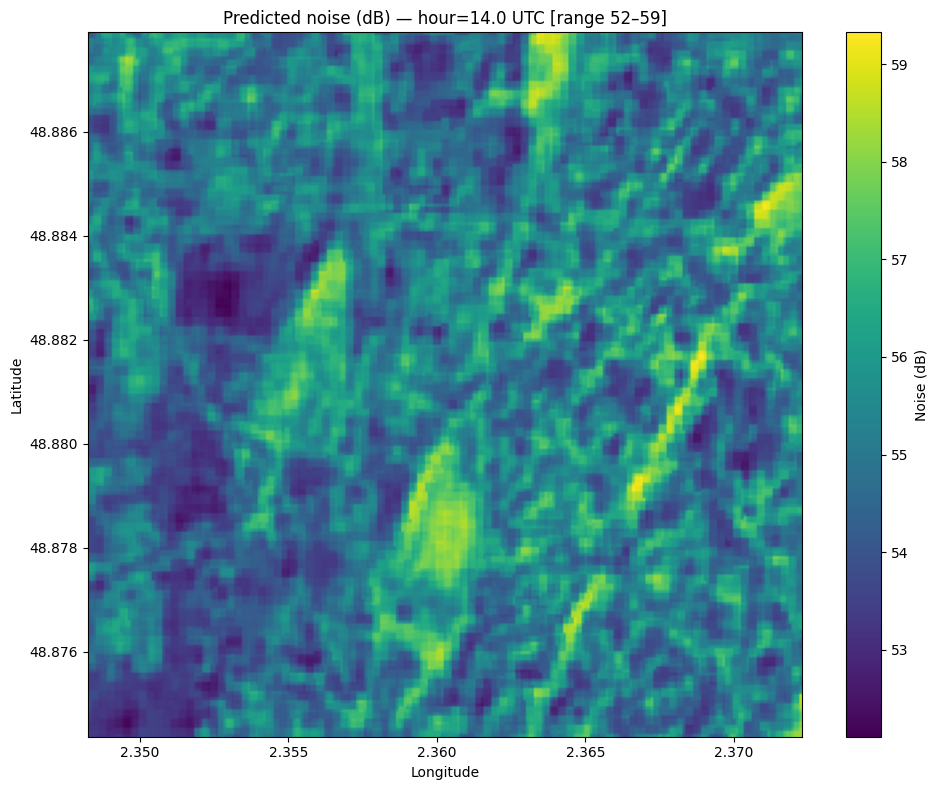

Map(center=[48.9, 2.35], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

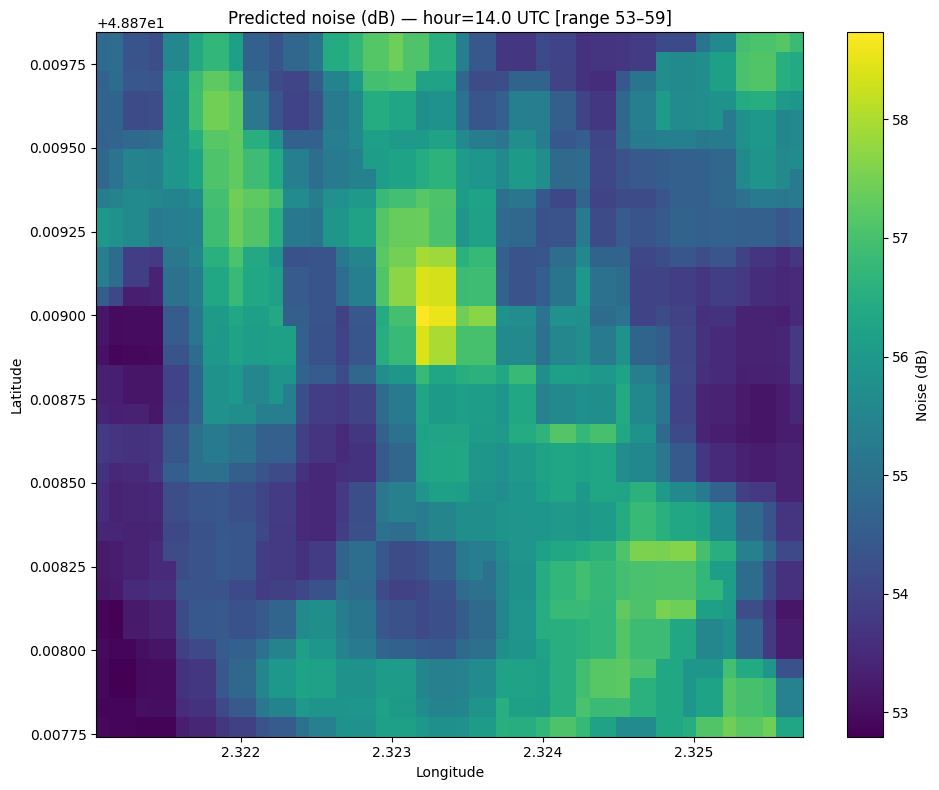

In [16]:
resolution = 10       # meters per pixel (smaller = finer, slower)
MAX_PIXELS = 300_000   # subsample if grid is larger
hour = 14.0            # UTC hour for prediction (edit if needed)

def run_heatmap_demo(bbox, hour, resolution=100, max_pixels=MAX_PIXELS):
  try:
    import asyncio
    import nest_asyncio
    nest_asyncio.apply()
    from pyproj import Transformer
    from odc.geo.geobox import GeoBox
    from aef_loader import AEFIndex, VirtualTiffReader, DataSource
    from aef_loader.utils import dequantize_aef, reproject_datatree
  except ImportError as e:
    print('Install aef-loader and odc-geo for the heatmap demo:')
    print('  pip install aef-loader odc-geo pyproj nest_asyncio')
    return

  target_crs = 'EPSG:3857'
  year = 2024
  transformer = Transformer.from_crs('EPSG:4326', target_crs, always_xy=True)
  inv_transformer = Transformer.from_crs(target_crs, 'EPSG:4326', always_xy=True)
  x_min, y_min = transformer.transform(bbox[0], bbox[1])
  x_max, y_max = transformer.transform(bbox[2], bbox[3])
  geobox = GeoBox.from_bbox(bbox=(x_min, y_min, x_max, y_max), crs=target_crs, resolution=resolution)

  # Same AEF product as prep_data.py (Google EE). SOURCE_COOP = public mirror, no auth needed.
  async def load_aef():
    index = AEFIndex(source=DataSource.SOURCE_COOP)
    await index.download()
    tiles = await index.query(bbox=bbox, years=(year, year))
    async with VirtualTiffReader() as reader:
      tree = await reader.open_tiles_by_zone(tiles)
    combined = reproject_datatree(tree, target_geobox=geobox)
    emb = combined.embeddings.isel(time=0)
    if hasattr(emb, 'data') and hasattr(emb.data, 'compute'):
      emb = emb.compute()
    raw = dequantize_aef(emb).values
    return np.moveaxis(raw, 0, -1)

  try:
    loop = asyncio.get_running_loop()
  except RuntimeError:
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
  aef_grid = loop.run_until_complete(load_aef())
  H, W = aef_grid.shape[0], aef_grid.shape[1]
  n_full = H * W
  if n_full > max_pixels:
    stride = max(1, int((n_full / max_pixels) ** 0.5))
    aef_grid = aef_grid[::stride, ::stride, :].copy()
    H, W = aef_grid.shape[0], aef_grid.shape[1]
  aef_flat = aef_grid.reshape(-1, 64)

  transform = geobox.transform
  lons, lats = [], []
  for i in range(H):
    for j in range(W):
      x_proj, y_proj = transform * (j + 0.5, i + 0.5)
      lon, lat = inv_transformer.transform(x_proj, y_proj)
      lons.append(lon)
      lats.append(lat)
  lons = np.array(lons).reshape(H, W)
  lats = np.array(lats).reshape(H, W)

  hour_sin = np.sin(2 * np.pi * hour / 24)
  hour_cos = np.cos(2 * np.pi * hour / 24)
  country_onehot = np.zeros((H * W, len(country_classes)), dtype=np.float32)
  country_onehot[:, 0] = 1.0

  X_demo = np.hstack([
    aef_flat,
    lats.ravel()[:, None], lons.ravel()[:, None],
    np.full((H * W, 1), hour_sin), np.full((H * W, 1), hour_cos),
    country_onehot
  ]).astype(np.float32)
  X_demo_s = scaler.transform(X_demo)

  model.eval()
  pred_demo = []
  batch_size = 8192
  with torch.no_grad():
    for i in range(0, len(X_demo_s), batch_size):
      xb = torch.from_numpy(X_demo_s[i:i+batch_size]).to(device)
      pred_demo.append(model(xb).cpu().numpy())
  pred_demo = np.concatenate(pred_demo).reshape(H, W)

  extent = [bbox[0], bbox[2], bbox[1], bbox[3]]
  vmin, vmax = float(np.nanmin(pred_demo)), float(np.nanmax(pred_demo))
  fig, ax = plt.subplots(figsize=(10, 8))
  im = ax.imshow(pred_demo, extent=extent, origin='upper', aspect='auto',
                 cmap='viridis', vmin=vmin, vmax=vmax)
  ax.set_xlabel('Longitude')
  ax.set_ylabel('Latitude')
  ax.set_title(f'Predicted noise (dB) — hour={hour} UTC [range {vmin:.0f}–{vmax:.0f}]')
  plt.colorbar(im, ax=ax, label='Noise (dB)')
  plt.tight_layout()
  plt.show()

# --- Map: draw a rectangle, then click "Generate noisemap" ---
last_bbox = [2.2, 48.8, 2.5, 49.0]  # default Paris area [west, south, east, north]

try:
  from ipyleaflet import Map, DrawControl, WidgetControl
  import ipywidgets as widgets

  m = Map(center=(48.9, 2.35), zoom=10, scroll_wheel_zoom=True)
  draw = DrawControl(
    rectangle={'shapeOptions': {'color': '#3388ff', 'fillOpacity': 0.3}},
    polygon={}, circle={}, polyline={}, circlemarker={},
  )

  def bbox_from_draw_data(data):
    if not data or len(data) == 0:
      return None
    f = data[-1]
    geom = f.get('geometry', {})
    if geom.get('type') != 'Polygon' or 'coordinates' not in geom:
      return None
    ring = geom['coordinates'][0]
    lons = [p[0] for p in ring]
    lats = [p[1] for p in ring]
    return [min(lons), min(lats), max(lons), max(lats)]

  def on_draw_change(change):
    global last_bbox
    b = bbox_from_draw_data(draw.data)
    if b is not None:
      last_bbox = b
      btn.description = 'Generate noisemap (region updated)'

  draw.observe(on_draw_change, names=['data'])
  m.add_control(draw)

  def on_click(btn):
    btn.description = 'Loading AEF & predicting...'
    try:
      run_heatmap_demo(last_bbox, hour, resolution, MAX_PIXELS)
    finally:
      btn.description = 'Generate noisemap'

  btn = widgets.Button(description='Generate noisemap', button_style='primary')
  btn.on_click(on_click)
  m.add_control(WidgetControl(widget=btn, position='topright'))

  display(m)
except Exception as e:
  print('Map widget not available:', e)
  print('Run with a default region (Paris area):')
  run_heatmap_demo(last_bbox, hour, resolution, MAX_PIXELS)

In [ ]:
# Draw a rectangle on the map above (toolbar on the left), then click "Generate noisemap".